# 03. Feature Engineering & Dataset Preparation
**GitAI — Data-Driven GitHub Intelligence & Trend Prediction**

---

### Phase 5B Objectives:
1. **Target Variable Creation**: Formulate `popularity_class` ($	ext{stars} > 2,000 ightarrow 1$, $\le 2,000 ightarrow 0$) based on the Phase 5A problem definition.
2. **Core Feature Engineering**:
   - *Engagement*: $\log_{1p}(	ext{forks})$, $\log_{1p}(	ext{open\_issues})$
   - *Temporal*: `repo_age_days`, `repo_age_years`, `days_since_last_push` (relative to $T_{\text{snapshot}}$)
   - *Topics*: `topic_count`, `has_topics` (binary 0/1)
   - *Description*: `has_description` (binary 0/1), `description_length` (character count)
   - *License*: `has_license` (binary 0/1)
   - *Language*: Preserved as categorical for pipeline encoding
3. **Experimental Features**: `forks_per_year`, `issues_per_year` (with zero-division protection)
4. **Target Leakage Prevention**: Programmatic verification ensuring strict exclusion of `stars`, `watchers`, and star-derived ratios.
5. **Feature Validation & Serialization**: Save the final ML-ready feature matrix to `data/processed/github_repositories_ml.csv`.

> **Guiding Policy:**
> - No model training, train/test splitting, or ML hyperparameter tuning in this notebook.
> - Preserves raw (`data/raw/`) and cleaned (`data/processed/github_repositories_cleaned.csv`) datasets.


In [1]:
# 1. Imports and Environment Setup
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (10, 5)

# Resolve paths
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
cleaned_csv_path = project_root / "data" / "processed" / "github_repositories_cleaned.csv"
ml_csv_path = project_root / "data" / "processed" / "github_repositories_ml.csv"

# Add src to sys.path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.preprocessor import DataPreprocessor

print(f"Project root:        {project_root}")
print(f"Cleaned CSV input:   {cleaned_csv_path}")
print(f"ML dataset target:   {ml_csv_path}")
assert cleaned_csv_path.exists(), f"Cleaned dataset not found at {cleaned_csv_path}!"


Project root:        /Users/vedantburgul/Desktop/GitAI
Cleaned CSV input:   /Users/vedantburgul/Desktop/GitAI/data/processed/github_repositories_cleaned.csv
ML dataset target:   /Users/vedantburgul/Desktop/GitAI/data/processed/github_repositories_ml.csv


In [2]:
# 2. Load Cleaned Dataset
df_cleaned = pd.read_csv(cleaned_csv_path, keep_default_na=False)

print("=" * 60)
print("CLEANED DATASET OVERVIEW")
print("=" * 60)
print(f"Total Records: {df_cleaned.shape[0]}")
print(f"Total Columns: {df_cleaned.shape[1]}")
print("\nColumns:", list(df_cleaned.columns))
df_cleaned.head(3)


CLEANED DATASET OVERVIEW
Total Records: 2520
Total Columns: 14

Columns: ['id', 'repository_name', 'owner', 'full_name', 'description', 'language', 'stars', 'forks', 'open_issues', 'topics', 'created_at', 'updated_at', 'pushed_at', 'license']


,id,repository_name,owner,full_name,description,language,stars,forks,open_issues,topics,created_at,updated_at,pushed_at,license
0,1207590198,memkraft,seojoonkim,seojoonkim/memkraft,Ultimate zero-dependency compound knowledge sy...,Python,200,24,15,,2026-04-11T06:03:29Z,2026-09-01T04:00:37Z,2026-08-20T14:26:35Z,MIT
1,656700998,nanoRWKV,Hannibal046,Hannibal046/nanoRWKV,The nanoGPT-style implementation of RWKV Langu...,Python,200,14,1,,2023-06-21T13:09:10Z,2026-09-01T04:00:19Z,2023-11-09T07:32:20Z,MIT
2,841427341,automated-prompt-engineering-from-scratch,heiko-hotz,heiko-hotz/automated-prompt-engineering-from-s...,A repo with an automated prompt engineering wo...,Python,200,34,0,,2024-08-12T11:41:09Z,2026-09-01T04:00:24Z,2024-09-11T11:08:09Z,Other


In [3]:
# 3. Execute Feature Engineering Pipeline
preprocessor = DataPreprocessor()
df_ml, audit_report = preprocessor.engineer_features(df_cleaned)

# Save to data/processed/github_repositories_ml.csv
preprocessor.save_cleaned_data(df_ml, ml_csv_path)

print("=" * 60)
print("FEATURE ENGINEERING AUDIT REPORT")
print("=" * 60)
print(f"Total Rows:              {audit_report['total_rows']}")
print(f"Total Columns:           {audit_report['total_columns']}")
print(f"All Audit Checks Passed: {audit_report['passed_all_checks']}")
print("\nTarget Distribution:")
for k, v in audit_report["target_distribution"].items():
    print(f"  {k:<22}: {v}")

print("\nLeakage Audit Status:")
print(f"  Passed:                {audit_report['leakage_check']['passed']}")
print(f"  Leaking Features:      {audit_report['leakage_check']['leaking_features_found']}")


2026-09-01 16:40:25,361 [INFO] Saved dataset (2520 records) to /Users/vedantburgul/Desktop/GitAI/data/processed/github_repositories_ml.csv


FEATURE ENGINEERING AUDIT REPORT
Total Rows:              2520
Total Columns:           14
All Audit Checks Passed: True

Target Distribution:
  High_Popularity (1)   : 840
  Lower_Popularity (0)  : 1680
  High_Popularity_Pct   : 33.33
  Lower_Popularity_Pct  : 66.67

Leakage Audit Status:
  Passed:                True
  Leaking Features:      []


In [4]:
# 4. Target Distribution Validation
target_counts = df_ml["popularity_class"].value_counts()
target_pcts = df_ml["popularity_class"].value_counts(normalize=True) * 100

target_val_df = pd.DataFrame({
    "Class Label": ["0 (Lower Popularity: <=2,000 stars)", "1 (High Popularity: >2,000 stars)"],
    "Count": [target_counts[0], target_counts[1]],
    "Percentage (%)": [target_pcts[0], target_pcts[1]],
    "Expected Count (Phase 5A)": [1680, 840],
    "Status": ["Match" if target_counts[0] == 1680 else "Mismatch",
               "Match" if target_counts[1] == 840 else "Mismatch"]
}).set_index("Class Label")

print("=" * 60)
print("TARGET CLASS VALIDATION")
print("=" * 60)
print(target_val_df)
assert target_counts[1] == 840 and target_counts[0] == 1680, "Target class count mismatch!"
print("\nTarget validation successfully verified: Exactly 840 High Popularity and 1,680 Lower Popularity.")


TARGET CLASS VALIDATION
                                     Count  Percentage (%)  \
Class Label                                                  
0 (Lower Popularity: <=2,000 stars)   1680       66.666667   
1 (High Popularity: >2,000 stars)      840       33.333333   

                                     Expected Count (Phase 5A) Status  
Class Label                                                            
0 (Lower Popularity: <=2,000 stars)                       1680  Match  
1 (High Popularity: >2,000 stars)                          840  Match  

Target validation successfully verified: Exactly 840 High Popularity and 1,680 Lower Popularity.


In [5]:
# 5. Programmatic Target Leakage Audit
ml_feature_names = [c for c in df_ml.columns if c != "popularity_class"]

forbidden_substrings = ["star", "watcher"]
detected_leakage = []

for feat in ml_feature_names:
    for sub in forbidden_substrings:
        if sub in feat.lower():
            detected_leakage.append((feat, sub))

print("=" * 60)
print("STRICT TARGET LEAKAGE AUDIT")
print("=" * 60)
print(f"Total ML Features Tested: {len(ml_feature_names)}")
print("Feature List:", ml_feature_names)
print(f"Forbidden Substrings Tested: {forbidden_substrings}")

if len(detected_leakage) == 0:
    print("\n[PASS] No star-derived or watcher-derived features detected in ML feature matrix.")
else:
    print(f"\n[FAIL] LEAKAGE DETECTED: {detected_leakage}")
    raise AssertionError(f"Target leakage detected in features: {detected_leakage}")


STRICT TARGET LEAKAGE AUDIT
Total ML Features Tested: 13
Feature List: ['log_forks', 'log_open_issues', 'repo_age_days', 'repo_age_years', 'days_since_last_push', 'topic_count', 'has_topics', 'has_description', 'description_length', 'has_license', 'language', 'forks_per_year', 'issues_per_year']
Forbidden Substrings Tested: ['star', 'watcher']

[PASS] No star-derived or watcher-derived features detected in ML feature matrix.


In [6]:
# 6. Detailed Range, Null, and Infinite Value Validation
numeric_cols = df_ml.select_dtypes(include=[np.number]).columns

validation_table = []
for col in numeric_cols:
    s = df_ml[col]
    validation_table.append({
        "Feature": col,
        "Data_Type": str(s.dtype),
        "Null_Count": int(s.isnull().sum()),
        "Inf_Count": int(np.isinf(s).sum()),
        "Negative_Count": int((s < 0).sum()),
        "Min": round(float(s.min()), 4),
        "P25": round(float(s.quantile(0.25)), 4),
        "Median": round(float(s.median()), 4),
        "Mean": round(float(s.mean()), 4),
        "P75": round(float(s.quantile(0.75)), 4),
        "Max": round(float(s.max()), 4),
        "Std_Dev": round(float(s.std()), 4)
    })

val_df = pd.DataFrame(validation_table).set_index("Feature")
print("=" * 60)
print("ENGINEERED FEATURES VALIDATION SUMMARY")
print("=" * 60)
val_df


ENGINEERED FEATURES VALIDATION SUMMARY


,Data_Type,Null_Count,Inf_Count,Negative_Count,Min,P25,Median,Mean,P75,Max,Std_Dev
Feature,,,,,,,,,,,
log_forks,float64,0,0,0,0.0000,4.0431,5.4467,5.8042,7.7092,11.5972,2.2456
log_open_issues,float64,0,0,0,0.0000,1.9459,3.3322,3.4640,4.9218,10.5536,2.1475
repo_age_days,float64,0,0,0,11.4979,1804.9320,3180.8313,3093.2032,4380.4304,6791.7297,1645.7460
repo_age_years,float64,0,0,0,0.0315,4.9416,8.7086,8.4687,11.9930,18.5947,4.5058
days_since_last_push,float64,0,0,0,0.0000,1.4128,75.0056,619.7834,903.4559,6078.3603,982.6951
topic_count,int64,0,0,0,0.0000,0.0000,4.0000,5.5623,9.0000,20.0000,5.8410
has_topics,int64,0,0,0,0.0000,0.0000,1.0000,0.6655,1.0000,1.0000,0.4719
has_description,int64,0,0,0,0.0000,1.0000,1.0000,0.9762,1.0000,1.0000,0.1525
description_length,int64,0,0,0,0.0000,38.0000,60.0000,78.1194,93.2500,5835.0000,132.2714


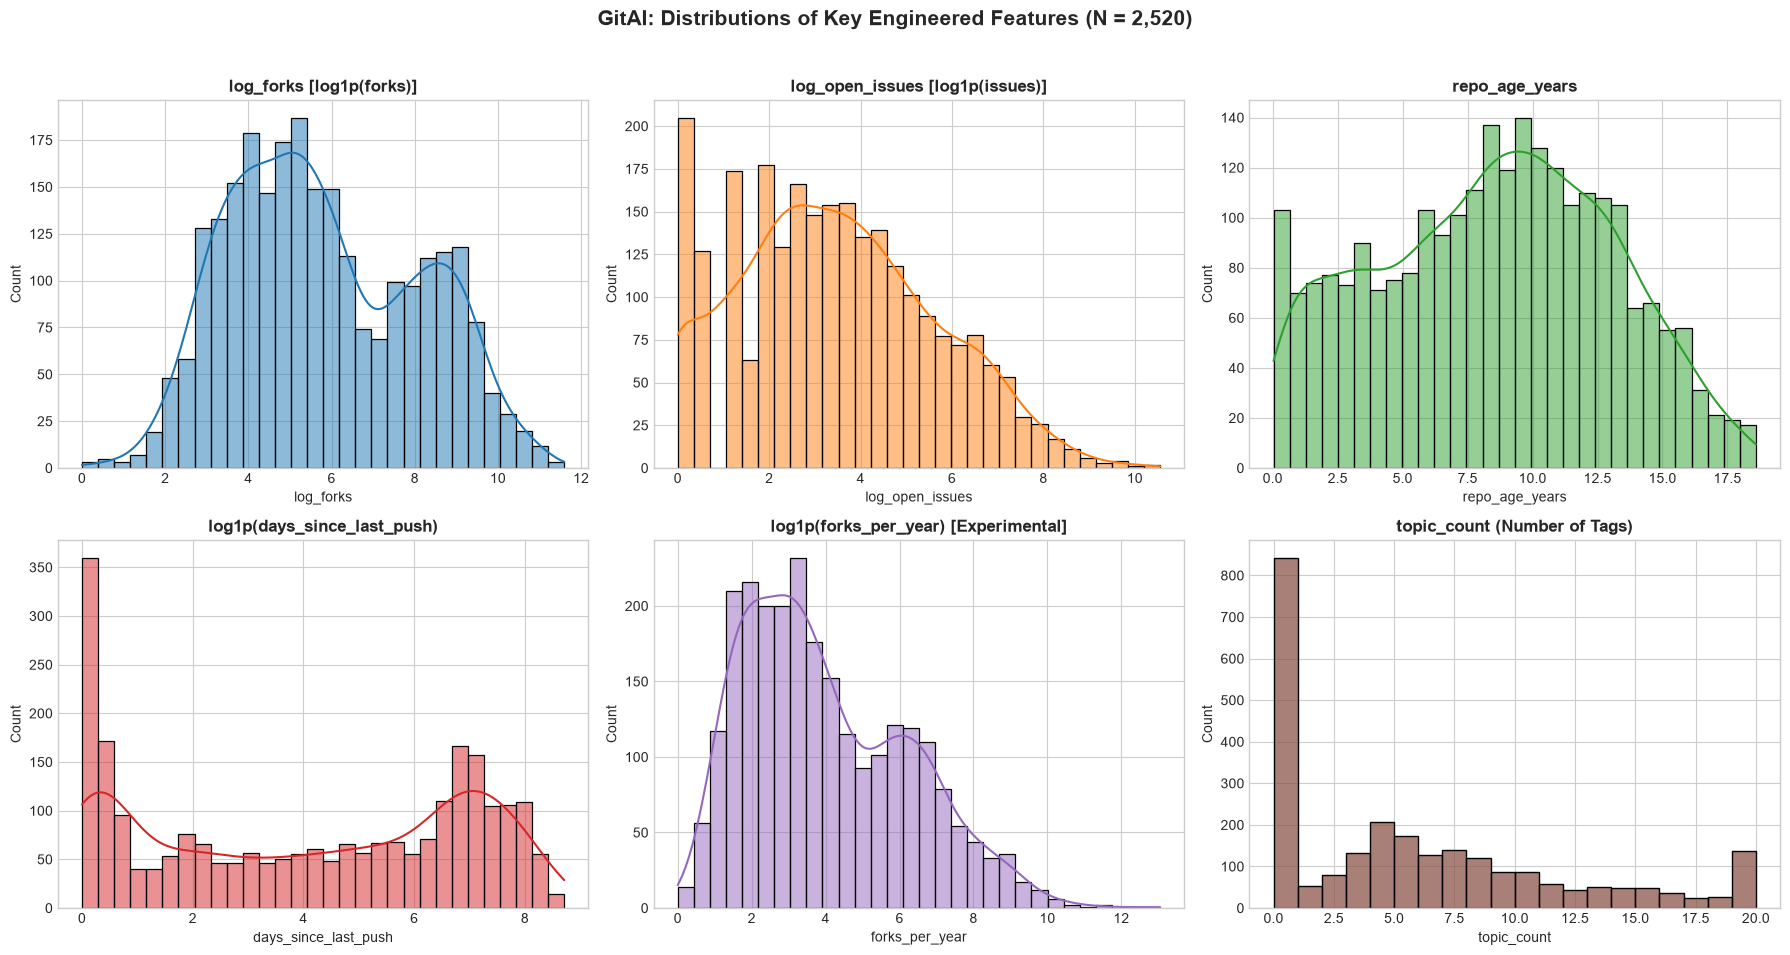

In [7]:
# 7. Distribution of Key Engineered Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("GitAI: Distributions of Key Engineered Features (N = 2,520)", fontsize=15, fontweight='bold')

# 1. log_forks
sns.histplot(df_ml["log_forks"], bins=30, kde=True, color="#1f77b4", ax=axes[0, 0])
axes[0, 0].set_title("log_forks [log1p(forks)]", fontweight='bold')

# 2. log_open_issues
sns.histplot(df_ml["log_open_issues"], bins=30, kde=True, color="#ff7f0e", ax=axes[0, 1])
axes[0, 1].set_title("log_open_issues [log1p(issues)]", fontweight='bold')

# 3. repo_age_years
sns.histplot(df_ml["repo_age_years"], bins=30, kde=True, color="#2ca02c", ax=axes[0, 2])
axes[0, 2].set_title("repo_age_years", fontweight='bold')

# 4. days_since_last_push
sns.histplot(np.log1p(df_ml["days_since_last_push"]), bins=30, kde=True, color="#d62728", ax=axes[1, 0])
axes[1, 0].set_title("log1p(days_since_last_push)", fontweight='bold')

# 5. forks_per_year (Log scale)
sns.histplot(np.log1p(df_ml["forks_per_year"]), bins=30, kde=True, color="#9467bd", ax=axes[1, 1])
axes[1, 1].set_title("log1p(forks_per_year) [Experimental]", fontweight='bold')

# 6. topic_count
sns.histplot(df_ml["topic_count"], bins=20, color="#8c564b", ax=axes[1, 2])
axes[1, 2].set_title("topic_count (Number of Tags)", fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


## 8. Feature Dictionary (ML Dataset)

| # | Feature Name | Definition / Formula | Data Type | Purpose / Description | Leakage Status | Category |
| :---: | :--- | :--- | :--- | :--- | :---: | :---: |
| 1 | `popularity_class` | $\mathbb{I}(	ext{stars} > 2,000)$ | Integer (`int64`) | **Binary Prediction Target** (1 = High Popularity, 0 = Lower Popularity). | **Target** | Target |
| 2 | `log_forks` | $\log_{1p}(	ext{forks})$ | Float (`float64`) | Log-transformed fork count. Measures magnitude of community code cloning/branching. | Clean / Independent | **Core** |
| 3 | `log_open_issues` | $\log_{1p}(	ext{open\_issues})$ | Float (`float64`) | Log-transformed open issue count. Proxy for active user backlog and project scale. | Clean / Independent | **Core** |
| 4 | `repo_age_days` | $T_{\text{snapshot}} - \text{created\_at}$ (days) | Float (`float64`) | Total chronological age in days from creation to dataset snapshot. | Clean / Temporal | **Core** |
| 5 | `repo_age_years` | $\text{repo\_age\_days} / 365.25$ | Float (`float64`) | Standardized repository lifespan in years. | Clean / Temporal | **Core** |
| 6 | `days_since_last_push` | $T_{\text{snapshot}} - \text{pushed\_at}$ (days) | Float (`float64`) | Maintenance recency metric. Days elapsed since the last commit push. | Clean / Temporal | **Core** |
| 7 | `topic_count` | Count of topic tags | Integer (`int64`) | Curation depth. Number of categorized tags assigned to the repo. | Clean / Metadata | **Core** |
| 8 | `has_topics` | $\mathbb{I}(\text{topic\_count} > 0)$ | Integer (`int64`) | Binary indicator (1 if repository has $\ge 1$ topic tag, 0 otherwise). | Clean / Metadata | **Core** |
| 9 | `has_description` | $\mathbb{I}(\text{description} \neq \text{'No description'})$ | Integer (`int64`) | Binary indicator of whether repository owner provided a description. | Clean / Metadata | **Core** |
| 10 | `description_length` | $\text{len}(\text{description})$ | Integer (`int64`) | Character length of the repository description text (0 if absent). | Clean / Metadata | **Core** |
| 11 | `has_license` | $\mathbb{I}(\text{license} \neq \text{'No license specified'})$ | Integer (`int64`) | Binary indicator of formal open-source license specification. | Clean / Metadata | **Core** |
| 12 | `language` | Categorical string | String (`object`) | Primary programming language (10 categories + Unknown). Ready for pipeline encoding. | Clean / Categorical | **Core** |
| 13 | `forks_per_year` | $\text{forks} / \max(\text{age\_years}, \frac{1}{365.25})$ | Float (`float64`) | Annualized fork acquisition velocity. Protected against zero-division. | Clean / Rate Proxy | **Experimental** |
| 14 | `issues_per_year` | $\text{open\_issues} / \max(\text{age\_years}, \frac{1}{365.25})$ | Float (`float64`) | Annualized open issue creation rate. Protected against zero-division. | Clean / Rate Proxy | **Experimental** |


In [8]:
# 9. Verify File Persistence and Integrity
raw_csv_exists = (project_root / "data" / "raw" / "github_repositories_raw.csv").exists()
raw_json_exists = (project_root / "data" / "raw" / "github_repositories_raw.json").exists()
cleaned_csv_exists = (project_root / "data" / "processed" / "github_repositories_cleaned.csv").exists()
ml_csv_exists = (project_root / "data" / "processed" / "github_repositories_ml.csv").exists()

ml_size = ml_csv_path.stat().st_size if ml_csv_exists else 0

print("=" * 60)
print("FILE INTEGRITY & PERSISTENCE CHECK")
print("=" * 60)
print(f"Raw CSV Intact:        {raw_csv_exists}")
print(f"Raw JSON Intact:       {raw_json_exists}")
print(f"Cleaned CSV Intact:    {cleaned_csv_exists}")
print(f"ML CSV Created:        {ml_csv_exists} (Size: {ml_size:,} bytes)")

assert raw_csv_exists and raw_json_exists and cleaned_csv_exists and ml_csv_exists, "File integrity check failed!"
print("\nAll persistence assertions verified successfully.")


FILE INTEGRITY & PERSISTENCE CHECK
Raw CSV Intact:        True
Raw JSON Intact:       True
Cleaned CSV Intact:    True
ML CSV Created:        True (Size: 366,519 bytes)

All persistence assertions verified successfully.
